# Clase 02. ¿Cómo se mueve Santiago?

**INF-396 Introducción a la Ciencia de Datos**
Universidad Técnica Federico Santa María, Departamento de Informática

Repaso de Pandas y primera parte del análisis exploratorio de datos (unidad 2 del programa).

## El concepto de hoy: ¿de quién habla este número?

Ustedes ya trabajaron con Pandas, así que la mecánica de hoy va a paso de repaso. Lo
que esta clase agrega es una pregunta que van a usar toda la carrera: cada vez que
alguien les muestre una cifra (un promedio, un porcentaje, un total), pregúntense
**de quién está hablando ese número**.

Van a ver que todo lo de hoy es una variación de esa pregunta: un promedio puede
describir una situación en la que casi nadie está; contar filas de una encuesta habla
de la muestra y no de la ciudad; y hay personas de las que la tabla no dice nada, y
ese silencio también es información.

En vez de recorrer funciones una por una, le haremos preguntas reales a los datos y
dejaremos que cada pregunta traiga su herramienta.

## Los datos: la Encuesta Origen Destino de Santiago

La **EOD 2012** es la encuesta de movilidad más completa que se ha hecho en Chile:
levantada para [SECTRA](https://www.sectra.gob.cl/biblioteca/detalle1.asp?mfn=3253)
por la Universidad Alberto Hurtado, registra todos los viajes que hicieron las
personas de una muestra de hogares del Gran Santiago durante un día.

Es una base **relacional**: viene en varias tablas que se conectan por identificadores.

| Tabla | Una fila es... | Se conecta por |
|-------|----------------|----------------|
| `Hogares.csv` | un hogar encuestado | `Hogar` |
| `personas.csv` | una persona de un hogar | `Hogar`, `Persona` |
| `viajes.csv` | un viaje de una persona | `Hogar`, `Persona`, `Viaje` |
| `tablas_parametros/` | el significado de cada código | según la tabla |

Este es el mismo tipo de estructura que van a encontrar en casi cualquier encuesta
seria (Casen, Censo, ENUSC): los datos en tablas normalizadas y los significados en
tablas de códigos.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 25)

RUTA = "datos/eod_stgo/"

## 1. ¿A quiénes les preguntaron?

Toda encuesta responde por su muestra, así que lo primero es saber quién está en ella.
Partimos por la tabla de personas. Repaso relámpago: `read_csv` con el separador
correcto (estos archivos usan punto y coma, y coma decimal), y las tres miradas de
siempre: `shape`, `head`, `info`.

In [2]:
personas = pd.read_csv(RUTA + "personas.csv", sep=";", decimal=",", low_memory=False)
hogares = pd.read_csv(RUTA + "Hogares.csv", sep=";", decimal=",", low_memory=False)

print(f"Personas encuestadas: {len(personas):,}")
print(f"Hogares encuestados:  {len(hogares):,}")

Personas encuestadas: 60,054
Hogares encuestados:  18,264


In [3]:
personas.head(3)

,Hogar,Persona,AnoNac,Sexo,Relacion,Viajes,LicenciaConducir,PaseEscolar,AdultoMayor,Estudios,Curso,Actividad,...,TieneIngresos,Ingreso,TramoIngreso,IngresoFinal,TramoIngresoFinal,IngresoImputado,Factor_LaboralNormal,Factor_SabadoNormal,Factor_DomingoNormal,Factor_LaboralEstival,Factor_FindesemanaEstival,Factor
0,100010,10001001,1958,1,1,2,3,2,2,4.0,8.0,A,...,1,240000,2,240000,2,0,NaN,NaN,1668.2600,NaN,NaN,82.58553
1,100010,10001002,1956,2,2,5,1,2,2,5.0,1.0,D,...,2,0,0,0,0,0,NaN,NaN,852.1137,NaN,NaN,99.53422
2,100010,10001003,1982,2,3,0,1,2,2,7.0,4.0,A,...,1,99,2,210845,2,2,NaN,NaN,1609.1630,NaN,NaN,151.59367


In [4]:
personas.info()

<class 'pandas.DataFrame'>
RangeIndex: 60054 entries, 0 to 60053
Data columns (total 39 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Hogar                      60054 non-null  int64  
 1   Persona                    60054 non-null  int64  
 2   AnoNac                     60054 non-null  int64  
 3   Sexo                       60054 non-null  int64  
 4   Relacion                   60054 non-null  int64  
 5   Viajes                     60054 non-null  int64  
 6   LicenciaConducir           60054 non-null  str    
 7   PaseEscolar                60054 non-null  int64  
 8   AdultoMayor                60054 non-null  int64  
 9   Estudios                   59932 non-null  float64
 10  Curso                      59932 non-null  float64
 11  Actividad                  57969 non-null  str    
 12  Ocupacion                  25586 non-null  float64
 13  ActividadEmpresa           25586 non-null  float64
 14  J

Dos observaciones antes de seguir.

Primero, `Persona` no es un identificador único por sí solo: se repite dentro de cada
hogar. La llave real es el par `(Hogar, Persona)`. Equivocarse con las llaves es la
fuente clásica de merges malos.

Segundo, no hay una columna de edad, pero sí el año de nacimiento. La encuesta se
terminó de levantar en 2013, así que **derivamos** la edad. Crear columnas nuevas a
partir de las existentes es pan de cada día en el análisis de datos.

In [5]:
personas["Edad"] = 2013 - personas["AnoNac"]
personas["Edad"].describe().round(1)

count    60054.0
mean        37.6
std         22.2
min          0.0
25%         19.0
50%         36.0
75%         54.0
max        109.0
Name: Edad, dtype: float64

## 2. ¿Quiénes son? El primer merge

Miremos la composición por sexo:

In [6]:
personas["Sexo"].value_counts()

Sexo
2    31679
1    28375
Name: count, dtype: int64

El resultado es correcto e inútil: ¿qué significa ser `1` o ser `2`? La encuesta
guarda **códigos**, y los significados viven en otra tabla. Esto no es una molestia:
es el diseño estándar de una base de datos, y la operación que conecta ambas cosas
es `merge`.

In [7]:
sexo = pd.read_csv(RUTA + "tablas_parametros/Sexo.csv", sep=";")
sexo

,Id,Sexo
0,1,Hombre
1,2,Mujer


In [8]:
personas = personas.merge(sexo, left_on="Sexo", right_on="Id", how="left",
                          suffixes=("_codigo", ""))
personas["Sexo"].value_counts(normalize=True).round(3)

Sexo
Mujer     0.528
Hombre    0.472
Name: proportion, dtype: float64

Regla de oro después de todo merge: revisar cuántas filas quedaron sin pareja. Un
código que no está en la tabla de parámetros produce `NaN` en silencio, y ese
silencio arruina análisis completos.

In [9]:
print(f"Personas sin sexo asignado tras el merge: {personas['Sexo'].isna().sum()}")

Personas sin sexo asignado tras el merge: 0


## 3. ¿Cuánto gana un hogar típico?

La tabla de hogares trae el ingreso mensual. Aquí aparece la pregunta central de la
estadística descriptiva: **¿qué número resume bien una distribución?**

In [10]:
hogares["IngresoHogar"].describe().round(0)

count       18264.0
mean       688274.0
std        728778.0
min             0.0
25%        300000.0
50%        507826.0
75%        841101.0
max      14800000.0
Name: IngresoHogar, dtype: float64

In [11]:
media = hogares["IngresoHogar"].mean()
mediana = hogares["IngresoHogar"].median()

print(f"Ingreso medio:   ${media:>12,.0f}")
print(f"Ingreso mediano: ${mediana:>12,.0f}")
print(f"La media es un {media / mediana - 1:.0%} más alta que la mediana")

Ingreso medio:   $     688,274
Ingreso mediano: $     507,826
La media es un 36% más alta que la mediana


La media queda muy por encima de la mediana porque los ingresos son **asimétricos**:
la mayoría de los hogares gana montos moderados y unos pocos ganan muchísimo, y esos
pocos arrastran el promedio hacia arriba. Decir "el hogar promedio gana $688 mil"
describe una situación en la que la mayoría de los hogares no está.

Es el mismo fenómeno de los sueldos en las noticias: cuando escuchen "el sueldo
promedio en Chile", pregúntense siempre dónde quedó la mediana.

Los **percentiles** cuentan la historia completa:

In [12]:
hogares["IngresoHogar"].quantile([0.10, 0.25, 0.50, 0.75, 0.90, 0.99]).round(0)

0.10     172000.0
0.25     300000.0
0.50     507826.0
0.75     841101.0
0.90    1336617.0
0.99    3292161.0
Name: IngresoHogar, dtype: float64

Un histograma deja ver la forma de la asimetría. En la próxima clase nos dedicamos en
serio a los métodos gráficos; por ahora, la versión rápida:

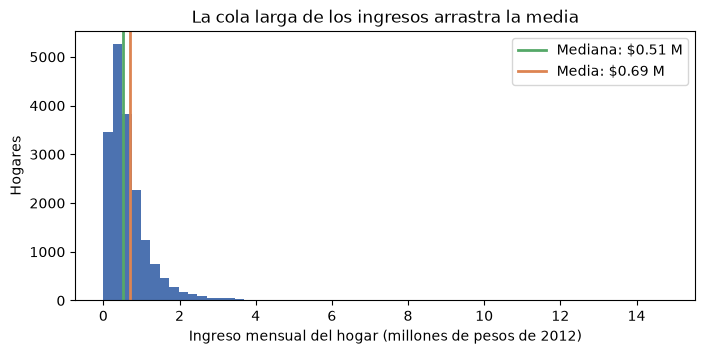

In [13]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(hogares["IngresoHogar"] / 1e6, bins=60, color="#4C72B0")
ax.axvline(mediana / 1e6, color="#55A868", linewidth=2, label=f"Mediana: ${mediana/1e6:.2f} M")
ax.axvline(media / 1e6, color="#DD8452", linewidth=2, label=f"Media: ${media/1e6:.2f} M")
ax.set_xlabel("Ingreso mensual del hogar (millones de pesos de 2012)")
ax.set_ylabel("Hogares")
ax.set_title("La cola larga de los ingresos arrastra la media")
ax.legend()
plt.show()

## 4. ¿Cuántos viajes hace una persona en un día?

Ahora necesitamos la tercera tabla. Cada fila de `viajes.csv` es un viaje, con su
origen, destino, propósito, modo y duración.

In [14]:
viajes = pd.read_csv(RUTA + "viajes.csv", sep=";", decimal=",", low_memory=False)
print(f"Viajes registrados: {len(viajes):,}")
viajes[["Hogar", "Persona", "Viaje", "ComunaOrigen", "ComunaDestino",
        "Proposito", "TiempoViaje"]].head()

Viajes registrados: 113,591


,Hogar,Persona,Viaje,ComunaOrigen,ComunaDestino,Proposito,TiempoViaje
0,173431,17343102,1734310202,94.0,94.0,7.0,70.0
1,173441,17344101,1734410101,94.0,71.0,1.0,105.0
2,173441,17344101,1734410102,71.0,94.0,7.0,90.0
3,173441,17344103,1734410301,94.0,91.0,1.0,55.0
4,173441,17344103,1734410302,91.0,94.0,7.0,150.0


La pregunta pide **contar viajes por persona**: un `groupby` sobre la llave compuesta.
Pero hay una trampa que distingue a quien explora bien de quien no: las personas que
no viajaron **no aparecen en la tabla de viajes**. Si solo agrupamos, las perdemos.

In [15]:
viajes_por_persona = viajes.groupby(["Hogar", "Persona"]).size()

# Alineamos contra TODAS las personas; quien no aparece, hizo 0 viajes.
conteo = personas.set_index(["Hogar", "Persona"]).assign(
    n_viajes=viajes_por_persona
)["n_viajes"].fillna(0)

print(f"Promedio de viajes por persona: {conteo.mean():.2f}")
print(f"Mediana de viajes por persona:  {conteo.median():.0f}")
print(f"Personas que no viajaron:       {(conteo == 0).mean():.1%}")

Promedio de viajes por persona: 1.89
Mediana de viajes por persona:  2
Personas que no viajaron:       23.0%


Fíjense en la rareza: aquí la media (1,9) quedó **por debajo** de la mediana (2). La
asimetría no siempre empuja hacia el mismo lado: casi un cuarto de las personas no
viajó ese día, y ese bloque de ceros tira la media hacia abajo. Las medidas de
resumen no se interpretan de memoria, se interpretan mirando la distribución.

In [16]:
conteo.value_counts().sort_index().head(10)

n_viajes
0.0    13788
1.0     1331
2.0    35056
3.0     2390
4.0     5199
5.0      823
6.0      881
7.0      241
8.0      206
9.0       52
Name: count, dtype: int64

## 5. ¿A quién representa la encuesta? Los factores de expansión

Se encuestó a 60 mil personas, pero el Gran Santiago tiene millones. ¿Con qué derecho
decimos que estos datos hablan de la ciudad?

La respuesta es el **factor de expansión**: cada persona encuestada representa a un
número de personas parecidas a ella (misma zona, edad y perfil). Ese número viene
calculado en la columna `Factor_LaboralNormal` para un día laboral de temporada
normal. La suma de los factores estima el total de la población representada.

In [17]:
factor = personas["Factor_LaboralNormal"]
print(f"Personas en la muestra:               {factor.notna().sum():,}")
print(f"Población que representan (aprox.):   {factor.sum():,.0f}")

Personas en la muestra:               37,326
Población que representan (aprox.):   6,651,735


¿Y esto cambia las respuestas? Puede cambiarlas por completo. Comparemos la
proporción de mujeres en la muestra cruda contra la proporción **ponderada**, que es
la estimación válida para la ciudad:

In [18]:
cruda = personas["Sexo"].value_counts(normalize=True)

ponderada = (
    personas.dropna(subset=["Factor_LaboralNormal"])
    .groupby("Sexo")["Factor_LaboralNormal"].sum()
)
ponderada = ponderada / ponderada.sum()

comparacion = pd.DataFrame({"muestra": cruda, "ciudad (ponderada)": ponderada})
comparacion.round(3)

,muestra,ciudad (ponderada)
Sexo,,
Hombre,0.472,0.485
Mujer,0.528,0.515


La regla que hay que llevarse: **contar filas responde preguntas sobre la muestra;
sumar factores responde preguntas sobre la ciudad**. Toda cifra oficial que sale de
esta encuesta (y de la Casen, y de la ENUSC) está calculada con factores. En la
tabla de viajes el factor propio del viaje está en `FactorLaboralNormal`; los viajes
de fin de semana traen ese factor vacío, porque pertenecen a otra expansión.

## 6. ¿Cuánto dura un viaje?

`TiempoViaje` está en minutos.

In [19]:
duracion = viajes["TiempoViaje"].dropna()
duracion.describe().round(1)

count    113313.0
mean         36.9
std          36.1
min           0.0
25%          15.0
50%          30.0
75%          50.0
max        1335.0
Name: TiempoViaje, dtype: float64

La mediana dice que el viaje típico dura media hora. Pero miren el máximo: más de
1.300 minutos, es decir, **un viaje de 22 horas dentro de Santiago**. ¿Error de
digitación? ¿Alguien que anotó un viaje de días? ¿Un turno nocturno mal registrado?

Ese es el trabajo del análisis exploratorio: los valores extremos no se borran por
molestos; se investigan, y la decisión que se tome (mantener, corregir, excluir) se
declara. Veamos qué tan raros son:

In [20]:
print(duracion.quantile([0.90, 0.95, 0.99, 0.999]).round(0))
print(f"\nViajes de más de 3 horas: {(duracion > 180).sum():,} "
      f"({(duracion > 180).mean():.2%} del total)")

0.900     80.0
0.950     98.0
0.990    150.0
0.999    310.0
Name: TiempoViaje, dtype: float64

Viajes de más de 3 horas: 349 (0.31% del total)


## 7. ¿En qué se mueve Santiago?

Cerramos con la pregunta que da nombre a la encuesta. El modo de transporte para
difusión está en una tabla aparte (`ViajesDifusion.csv`), codificado, con su
respectiva tabla de parámetros: dos merges y un groupby ponderado.

In [21]:
modo_viaje = pd.read_csv(RUTA + "ViajesDifusion.csv", sep=";")
modo_nombres = pd.read_csv(RUTA + "tablas_parametros/ModoDifusion.csv", sep=";")

viajes_modo = (
    viajes.merge(modo_viaje, on="Viaje", how="left")
    .merge(modo_nombres, left_on="ModoDifusion", right_on="ID", how="left",
           suffixes=("_codigo", ""))
)
print(f"Viajes sin modo asignado: {viajes_modo['ModoDifusion'].isna().sum()}")

Viajes sin modo asignado: 0


In [22]:
reparto = (
    viajes_modo.dropna(subset=["FactorLaboralNormal"])
    .groupby("ModoDifusion")["FactorLaboralNormal"].sum()
    .sort_values(ascending=False)
)
(reparto / reparto.sum()).round(3)

ModoDifusion
Caminata                0.339
Bip!                    0.242
Auto                    0.234
Otros                   0.069
Bicicleta               0.038
Taxi Colectivo          0.034
Bip! - Otros Publico    0.019
Taxi                    0.016
Bip! - Otros Privado    0.009
Name: FactorLaboralNormal, dtype: float64

Esta tabla es la **partición modal** del Gran Santiago en día laboral: la cifra que
abre cualquier discusión de política de transporte. La calculamos nosotros, desde los
microdatos, con tres tablas y dos merges.

En la próxima clase la pregunta será cómo **mostrar** estos resultados: qué gráfico
compara bien estas categorías, y por qué el primero que uno hace casi nunca es el
correcto.

## 8. Síntesis: ¿de quién habla este número?

Repasamos las herramientas (merge, groupby, describe), pero el aprendizaje de hoy es
la pregunta. Aplíquenla a lo que hicimos:

- *"El hogar promedio gana $688 mil"*: ese número habla de casi nadie; la mayoría de
  los hogares gana menos. La mediana y los percentiles hablan del hogar típico.
- *"El 53% de los encuestados son mujeres"*: ese número habla de la **muestra**. Para
  hablar de la **ciudad** hay que sumar factores de expansión.
- *"Las personas hacen 1,9 viajes en promedio"*: solo si contamos a las que no
  viajaron, que no estaban en la tabla. El que falta también es parte de la respuesta.
- *"El sexo es 1 o 2"*: sin su tabla de códigos, un número no habla de nada.

La técnica es repaso; el hábito de interrogar cada cifra es lo que se llevan.

## Para practicar

1. ¿Qué proporción de los encuestados tiene licencia de conducir? ¿Cambia si la
   calcula ponderada por factor de expansión?
2. Calcule la edad mediana por comuna del hogar y encuentre las cinco comunas más
   jóvenes. Necesita un merge entre `personas` y `hogares`.
3. ¿Cuál es el propósito de viaje más frecuente después del regreso a casa? La tabla
   `tablas_parametros/Proposito.csv` traduce los códigos.
4. Los viajes en transporte público, ¿duran más o menos que los viajes en auto?
   Compare medianas, no medias, y explique por qué.

## Referencias y créditos

- SECTRA, Ministerio de Transportes (2014). *Encuesta Origen Destino de Viajes
  Santiago 2012*. https://www.sectra.gob.cl/biblioteca/detalle1.asp?mfn=3253
- El enfoque de este notebook (preguntas sobre la ciudad con la EOD y el uso de los
  factores de expansión) está inspirado en el material del curso de visualización de
  Eduardo Graells-Garrido: https://github.com/zorzalerrante/aves
- Bruce, P., Bruce, A. y Gedeck, P. (2020). *Practical Statistics for Data
  Scientists*, 2ª ed. O'Reilly. Capítulo 1.